In [11]:
# Install library yang dibutuhkan (jalankan sekali jika belum terinstall)
import subprocess, sys

libs = ['matplotlib', 'seaborn', 'pandas']
for lib in libs:
    try:
        __import__(lib)
        print(f'✅ {lib} sudah terinstall')
    except ImportError:
        print(f'📦 Menginstall {lib}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', lib, '-q'])
        print(f'✅ {lib} berhasil diinstall')


✅ matplotlib sudah terinstall
✅ seaborn sudah terinstall
✅ pandas sudah terinstall


---
## 1. Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

---
## 2. Load Dataset

In [6]:
df = pd.read_csv('Kelas G_Fixed Call Report (2).csv')
print('Shape dataset:', df.shape)
df.head()

Shape dataset: (107, 8)


,Year,Month,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
0,2025,Feb,155200,98964,3777,5773,3706,42980
1,2025,Jan,130982,87815,3217,4179,3178,32593
2,2024,Dec,133725,86832,3634,3735,3035,36489
3,2024,Nov,153698,93710,3010,4421,4133,48424
4,2024,Oct,214604,108207,6307,5792,8885,80804


---
## 3. Eksplorasi Data

In [7]:
print('Informasi Dataset:')
print(df.info())
print()
print('Statistik Deskriptif:')
df.describe()

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 8 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Year                                       107 non-null    int64
 1   Month                                      107 non-null    str  
 2   Total Number of Calls                      107 non-null    int64
 3   Total Number of Doctors Consultancy        107 non-null    int64
 4   Number of Total Health Information         107 non-null    int64
 5   Number of Total Ambulance Information      107 non-null    int64
 6   Number of Total Complaints                 107 non-null    int64
 7   Number of Calls To Know About The Service  107 non-null    int64
dtypes: int64(7), str(1)
memory usage: 6.8 KB
None

Statistik Deskriptif:


,Year,Total Number of Calls,Total Number of Doctors Consultancy,Number of Total Health Information,Number of Total Ambulance Information,Number of Total Complaints,Number of Calls To Know About The Service
count,107.000000,1.070000e+02,1.070000e+02,107.000000,107.000000,107.000000,107.000000
mean,2020.205607,2.340316e+05,1.544553e+05,15714.728972,9240.317757,6924.457944,47509.102804
std,2.601662,3.697001e+05,2.681351e+05,23104.165341,15330.680874,10484.201602,61227.797516
min,2016.000000,5.143200e+04,3.816200e+04,3010.000000,220.000000,77.000000,4075.000000
25%,2018.000000,9.918850e+04,6.081800e+04,6858.000000,836.000000,697.000000,18536.500000
50%,2020.000000,1.424000e+05,9.489300e+04,10841.000000,4734.000000,4133.000000,28895.000000
75%,2022.000000,2.025520e+05,1.215265e+05,13291.000000,8658.500000,8262.000000,45822.500000
max,2025.000000,2.329457e+06,1.703100e+06,173306.000000,91751.000000,59760.000000,342434.000000


In [8]:
print('Tahun yang tersedia:', sorted(df['Year'].unique()))
print('Total baris per tahun:')
print(df['Year'].value_counts().sort_index())

Tahun yang tersedia: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Total baris per tahun:
Year
2016     9
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025     2
Name: count, dtype: int64


---
## 4. Agregasi — Nilai Maksimum per Tahun

Menghitung nilai **maksimum** kolom `Number of Calls To Know About The Service` untuk setiap tahun.

In [9]:
# Agregasi: max per tahun
df_max = (
    df.groupby('Year')['Number of Calls To Know About The Service']
      .max()
      .reset_index()
)
df_max.columns = ['Year', 'Max_Calls_To_Know']

print('Hasil Agregasi — Nilai Maksimum per Tahun:')
print(df_max.to_string(index=False))
print()
print(f'Tahun dengan panggilan tertinggi: {df_max.loc[df_max["Max_Calls_To_Know"].idxmax(), "Year"]}')
print(f'Nilai maksimum keseluruhan     : {df_max["Max_Calls_To_Know"].max():,}')

Hasil Agregasi — Nilai Maksimum per Tahun:
 Year  Max_Calls_To_Know
 2016              19698
 2017              32241
 2018              27948
 2019              50963
 2020             342434
 2021             104105
 2022              60846
 2023              43221
 2024              80804
 2025              42980

Tahun dengan panggilan tertinggi: 2020
Nilai maksimum keseluruhan     : 342,434


---
## 5. Grafik 1 (Kategori A) — Bar Chart

Visualisasi hasil agregasi menggunakan **Bar Chart** dengan pendekatan objek (`ax = axes[x, y]`).

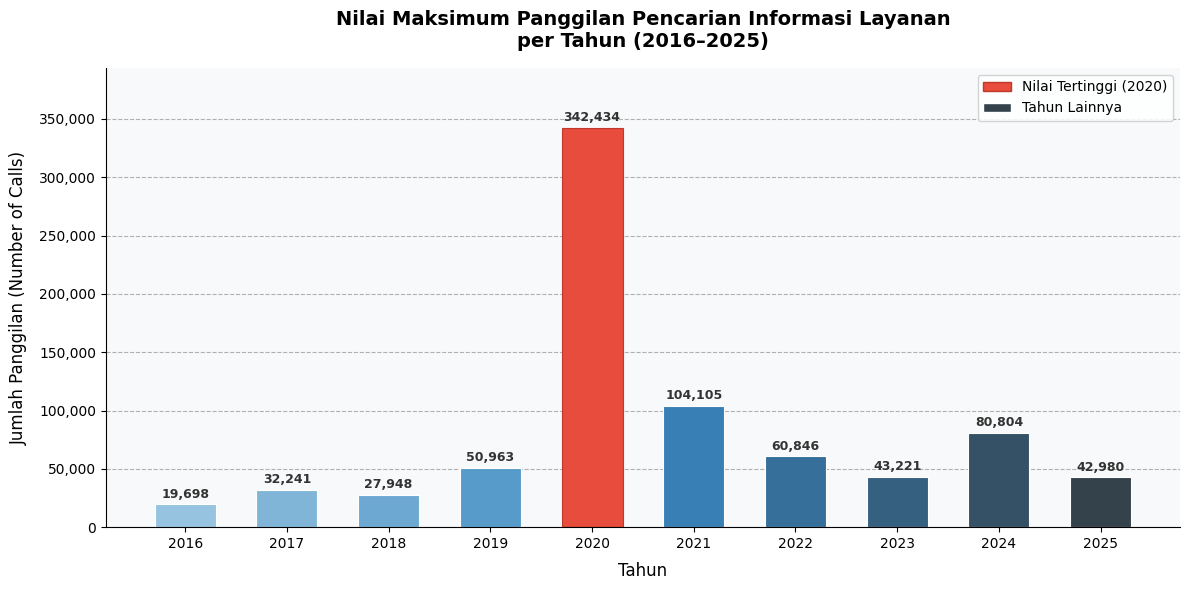

Grafik berhasil disimpan: grafik1_kategori_A_bar_chart.png


In [10]:
# ── Pendekatan objek agar mudah digabung ke Grafik-5 (plt.subplots 2x2) ──
fig, ax = plt.subplots(figsize=(12, 6))

# Palet warna: gradasi berdasarkan nilai
palette = sns.color_palette('Blues_d', n_colors=len(df_max))
colors  = [palette[i] for i in range(len(df_max))]

bars = ax.bar(
    df_max['Year'].astype(str),
    df_max['Max_Calls_To_Know'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)

# ── Anotasi nilai di atas setiap bar ──
for bar, val in zip(bars, df_max['Max_Calls_To_Know']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold', color='#333333'
    )

# ── Sorot bar tertinggi (2020) ──
idx_max = df_max['Max_Calls_To_Know'].idxmax()
bars[idx_max].set_color('#E74C3C')
bars[idx_max].set_edgecolor('#C0392B')

# ── Label & judul ──
ax.set_title(
    'Nilai Maksimum Panggilan Pencarian Informasi Layanan\nper Tahun (2016–2025)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Tahun', fontsize=12, labelpad=8)
ax.set_ylabel('Jumlah Panggilan (Number of Calls)', fontsize=12, labelpad=8)

# ── Format sumbu Y ──
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(0, df_max['Max_Calls_To_Know'].max() * 1.15)

# ── Grid & style ──
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.6, color='grey')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')
sns.despine(ax=ax, left=False, bottom=False)

# ── Legenda keterangan warna ──
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', edgecolor='#C0392B', label='Nilai Tertinggi (2020)'),
    Patch(facecolor=palette[-1],  edgecolor='white',  label='Tahun Lainnya'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10, framealpha=0.85)

plt.tight_layout()
plt.savefig('grafik1_kategori_A_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik berhasil disimpan: grafik1_kategori_A_bar_chart.png')

---
## 6. Analisis & Insight

**Temuan utama dari Bar Chart:**

1. **Lonjakan drastis tahun 2020** — Nilai maksimum mencapai **342.434 panggilan**, hampir **3,3× lebih tinggi** dibandingkan tahun sebelumnya (2019: 50.963). Lonjakan ini kemungkinan besar berkaitan dengan pandemi COVID-19, yang mendorong masyarakat mencari informasi layanan kesehatan secara masif.

2. **Tren penurunan pasca-2020** — Setelah puncak 2020, nilai maksimum turun secara bertahap: 2021 (104.105) → 2022 (60.846) → 2023 (43.221). Ini mengindikasikan aktivitas layanan mulai kembali normal.

3. **Rebound moderat di 2024** — Nilai naik kembali ke 80.804 di 2024, kemungkinan karena peningkatan volume layanan atau kampanye informasi publik baru.

4. **Tahun 2016 memiliki nilai terendah** (19.698), konsisten dengan periode awal operasional layanan.

**Kesimpulan:** Tahun **2020 menjadi anomali signifikan** dalam dataset ini dan perlu dipertimbangkan saat membandingkan tren antar tahun.